# Data Exploration - BRISC 2025 Brain MRI Dataset

This notebook explores the BRISC 2025 dataset before training the model.

The goal of this step is to understand the dataset structure, count the number of images in each class, check train/test distribution, visualize sample MRI images, and inspect image dimensions.

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

print("Data exploration started successfully.")

Data exploration started successfully.


## Dataset Path Check
Before exploring the dataset, we first verify that the training and testing directories exist and can be accessed correctly.

In [3]:
train_dir = "../data/raw/train"
test_dir = "../data/raw/test"

print("Train folder exists:", os.path.exists(train_dir))
print("Test folder exists:", os.path.exists(test_dir))

Train folder exists: True
Test folder exists: True


## Dataset Classes

The BRISC 2025 dataset contains four classes:
- glioma
- meningioma
- no_tumor
- pituitary

These classes represent different brain MRI categories used for tumor classification.

In [4]:
classes = sorted(os.listdir(train_dir))

print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Number of classes: 4


## Number of Images per Class

In this step, we count the number of MRI images in each class for both the training and testing sets.

This helps us understand the dataset size and check whether the classes are balanced before training the model.

In [5]:
data_counts = []

for split_name, split_dir in [("train", train_dir), ("test", test_dir)]:
    
    for class_name in sorted(os.listdir(split_dir)):
        
        class_path = os.path.join(split_dir, class_name)

        image_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        data_counts.append({
            "split": split_name,
            "class": class_name,
            "num_images": len(image_files)
        })

df_counts = pd.DataFrame(data_counts)

df_counts

,split,class,num_images
0,train,glioma,1147
1,train,meningioma,1329
2,train,no_tumor,1067
3,train,pituitary,1457
4,test,glioma,254
5,test,meningioma,306
6,test,no_tumor,140
7,test,pituitary,300


## Dataset Distribution Analysis

The BRISC 2025 dataset contains 6000 MRI images distributed across four classes.

The training set is relatively balanced across the four classes. However, the test set has fewer `no_tumor` images compared to the other classes.

Overall, the dataset size is suitable for training a pretrained deep learning model such as ResNet50.

## Visualizing Multiple Sample MRI Images

In this step, we display multiple MRI samples from each class instead of only one image.  
This gives a better visual overview of the dataset and helps us observe variations within each tumor type.

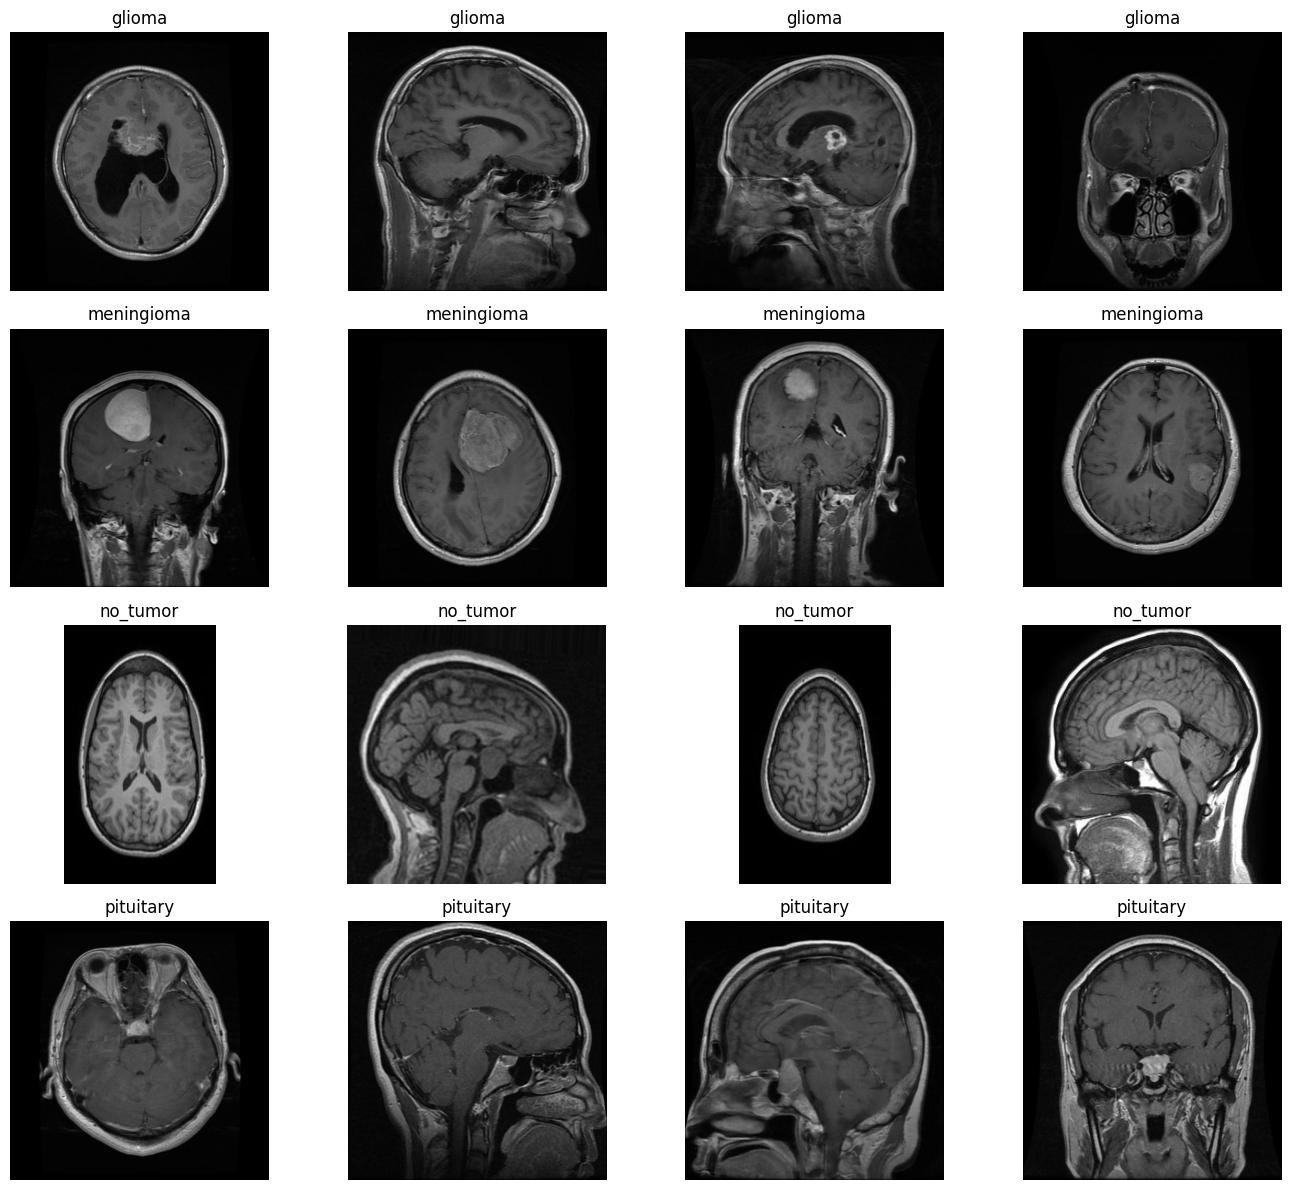

In [10]:
num_samples = 4

plt.figure(figsize=(14, 12))

for row, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    
    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ][:num_samples]
    
    for col, image_name in enumerate(image_files):
        image_path = os.path.join(class_path, image_name)
        img = Image.open(image_path)
        
        plt.subplot(len(classes), num_samples, row * num_samples + col + 1)
        plt.imshow(img, cmap="gray")
        plt.title(class_name)
        plt.axis("off")

plt.tight_layout()
plt.show()

## MRI Sample Analysis

The displayed MRI samples show visual variation within each class, not only between classes.

Tumor regions may appear in different shapes, sizes, and locations depending on the tumor type and the MRI view.  
The `no_tumor` class represents normal brain MRI scans without visible tumor regions.

Displaying multiple samples per class gives a more reliable understanding of the dataset than using only one image per class.

## Image Dimension Inspection

Before preprocessing, we inspect image dimensions to determine whether resizing will be required before training the model.

In [11]:
image_sizes = []
image_modes = []

for split_name, split_dir in [("train", train_dir), ("test", test_dir)]:
    for class_name in classes:
        class_path = os.path.join(split_dir, class_name)

        for image_name in os.listdir(class_path):
            if image_name.lower().endswith((".jpg", ".jpeg", ".png")):
                image_path = os.path.join(class_path, image_name)
                img = Image.open(image_path)

                image_sizes.append(img.size)
                image_modes.append(img.mode)

size_counts = pd.Series(image_sizes).value_counts()
mode_counts = pd.Series(image_modes).value_counts()

print("Most common image sizes:")
print(size_counts.head(10))

print("\nImage color modes:")
print(mode_counts)

Most common image sizes:
(512, 512)    4881
(369, 369)     363
(216, 369)     354
(256, 256)      32
(187, 369)      21
(225, 225)      20
(202, 369)      19
(210, 369)      12
(236, 236)      11
(442, 442)      10
Name: count, dtype: int64

Image color modes:
RGB    3134
L      2866
Name: count, dtype: int64


In [13]:
total_images = df_counts["num_images"].sum()

print(f"Total images: {total_images}")

print("\nWARNING: Mixed color modes detected!")
print(f"RGB      : {mode_counts.get('RGB', 0)} images")
print(f"Grayscale: {mode_counts.get('L', 0)} images")
print("All images must be converted to RGB during preprocessing.")

Total images: 6000

RGB      : 3134 images
Grayscale: 2866 images
All images must be converted to RGB during preprocessing.


## Image Dimension and Color Mode Analysis

We inspected the dimensions and color modes of all MRI images in both the training and testing sets.

Most MRI images have a resolution of 512×512, while some images have different dimensions.  
Therefore, resizing is required during preprocessing.

The dataset contains mixed color modes: 3134 RGB images and 2866 grayscale (L) images.  
During preprocessing, all images must be converted to a consistent RGB format before training.

Finally, all images will be resized to 224×224 to match the input size commonly used by pretrained models such as ResNet50 and MobileNet.

## Total Dataset Size

Finally, we calculate the total number of MRI images available in the dataset.


In [8]:
total_images = df_counts["num_images"].sum()

print("Total number of MRI images:", total_images)

Total number of MRI images: 6000


## EDA Summary

The BRISC 2025 dataset contains 6000 MRI images in total, divided into 5000 training images and 1000 testing images.

The dataset includes four classes: glioma, meningioma, no_tumor, and pituitary.  
The training set is relatively balanced, but the test set shows noticeable class imbalance, especially in the `no_tumor` class with 140 images compared to 306 images for meningioma.

Sample MRI images showed visible differences between the four classes, which can help the model learn meaningful visual patterns for classification.

The image dimension inspection showed that most images are 512×512, but some images have different dimensions.  
Therefore, all images will be resized to 224×224 during preprocessing.

The dataset also contains mixed color modes: 3134 RGB images and 2866 grayscale (L) images.  
Therefore, all images must be converted to RGB during preprocessing before training pretrained models such as ResNet50 and MobileNet.

This EDA confirms that the dataset is ready for preprocessing and model training.